In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv('weather_forecast_dataset.csv')

In [5]:
df.head()

,date,temperature_c,humidity_percent,wind_speed_kmph,pressure_hpa,cloud_cover_percent,dew_point_c,visibility_km,rainfall_mm
0,2018-01-01,23.11,51.49,18.68,1002.49,73.00,7.31,6.74,3.76
1,2018-01-02,43.28,57.87,16.65,1013.60,18.45,6.52,5.13,0.16
2,2018-01-03,35.62,88.36,8.81,1005.32,34.66,20.10,9.68,3.79
3,2018-01-04,30.95,47.20,30.36,983.75,66.33,29.15,2.97,0.38
4,2018-01-05,15.46,89.57,23.83,988.35,48.21,17.57,6.29,4.96


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 5000 non-null   object 
 1   temperature_c        5000 non-null   float64
 2   humidity_percent     5000 non-null   float64
 3   wind_speed_kmph      5000 non-null   float64
 4   pressure_hpa         5000 non-null   float64
 5   cloud_cover_percent  5000 non-null   float64
 6   dew_point_c          5000 non-null   float64
 7   visibility_km        5000 non-null   float64
 8   rainfall_mm          5000 non-null   float64
dtypes: float64(8), object(1)
memory usage: 351.7+ KB


In [8]:
df.shape

(5000, 9)

In [9]:
df.describe()

,temperature_c,humidity_percent,wind_speed_kmph,pressure_hpa,cloud_cover_percent,dew_point_c,visibility_km,rainfall_mm
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.389078,59.318976,25.068750,1002.845814,50.877708,17.283070,5.505472,3.952116
std,10.137227,22.849330,14.538533,12.951328,28.874203,7.113821,2.594962,3.910425
min,10.000000,20.000000,0.010000,980.010000,0.000000,5.000000,1.000000,0.000000
25%,18.535000,39.775000,12.360000,991.825000,25.887500,11.177500,3.230000,1.130000
50%,27.500000,58.875000,24.810000,1003.060000,51.335000,17.275000,5.520000,2.760000
75%,36.182500,78.670000,38.032500,1013.800000,75.765000,23.302500,7.730000,5.500000
max,44.990000,99.960000,49.990000,1025.000000,99.990000,29.990000,10.000000,28.880000


In [10]:
df.isnull().sum()

date                   0
temperature_c          0
humidity_percent       0
wind_speed_kmph        0
pressure_hpa           0
cloud_cover_percent    0
dew_point_c            0
visibility_km          0
rainfall_mm            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

# preprocessing

In [15]:
df['date'] =  pd.to_datetime(df['date'])
df = df.sort_values("date").reset_index(drop=True)

In [16]:
df.head()

,date,temperature_c,humidity_percent,wind_speed_kmph,pressure_hpa,cloud_cover_percent,dew_point_c,visibility_km,rainfall_mm
0,2018-01-01,23.11,51.49,18.68,1002.49,73.00,7.31,6.74,3.76
1,2018-01-02,43.28,57.87,16.65,1013.60,18.45,6.52,5.13,0.16
2,2018-01-03,35.62,88.36,8.81,1005.32,34.66,20.10,9.68,3.79
3,2018-01-04,30.95,47.20,30.36,983.75,66.33,29.15,2.97,0.38
4,2018-01-05,15.46,89.57,23.83,988.35,48.21,17.57,6.29,4.96


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_info ={}

for col in numeric_cols:
    Q1 ,Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outlier_info[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower': Q1 - 1.5 * IQR,
        'upper': Q3 + 1.5 * IQR,
        'mask': (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    }



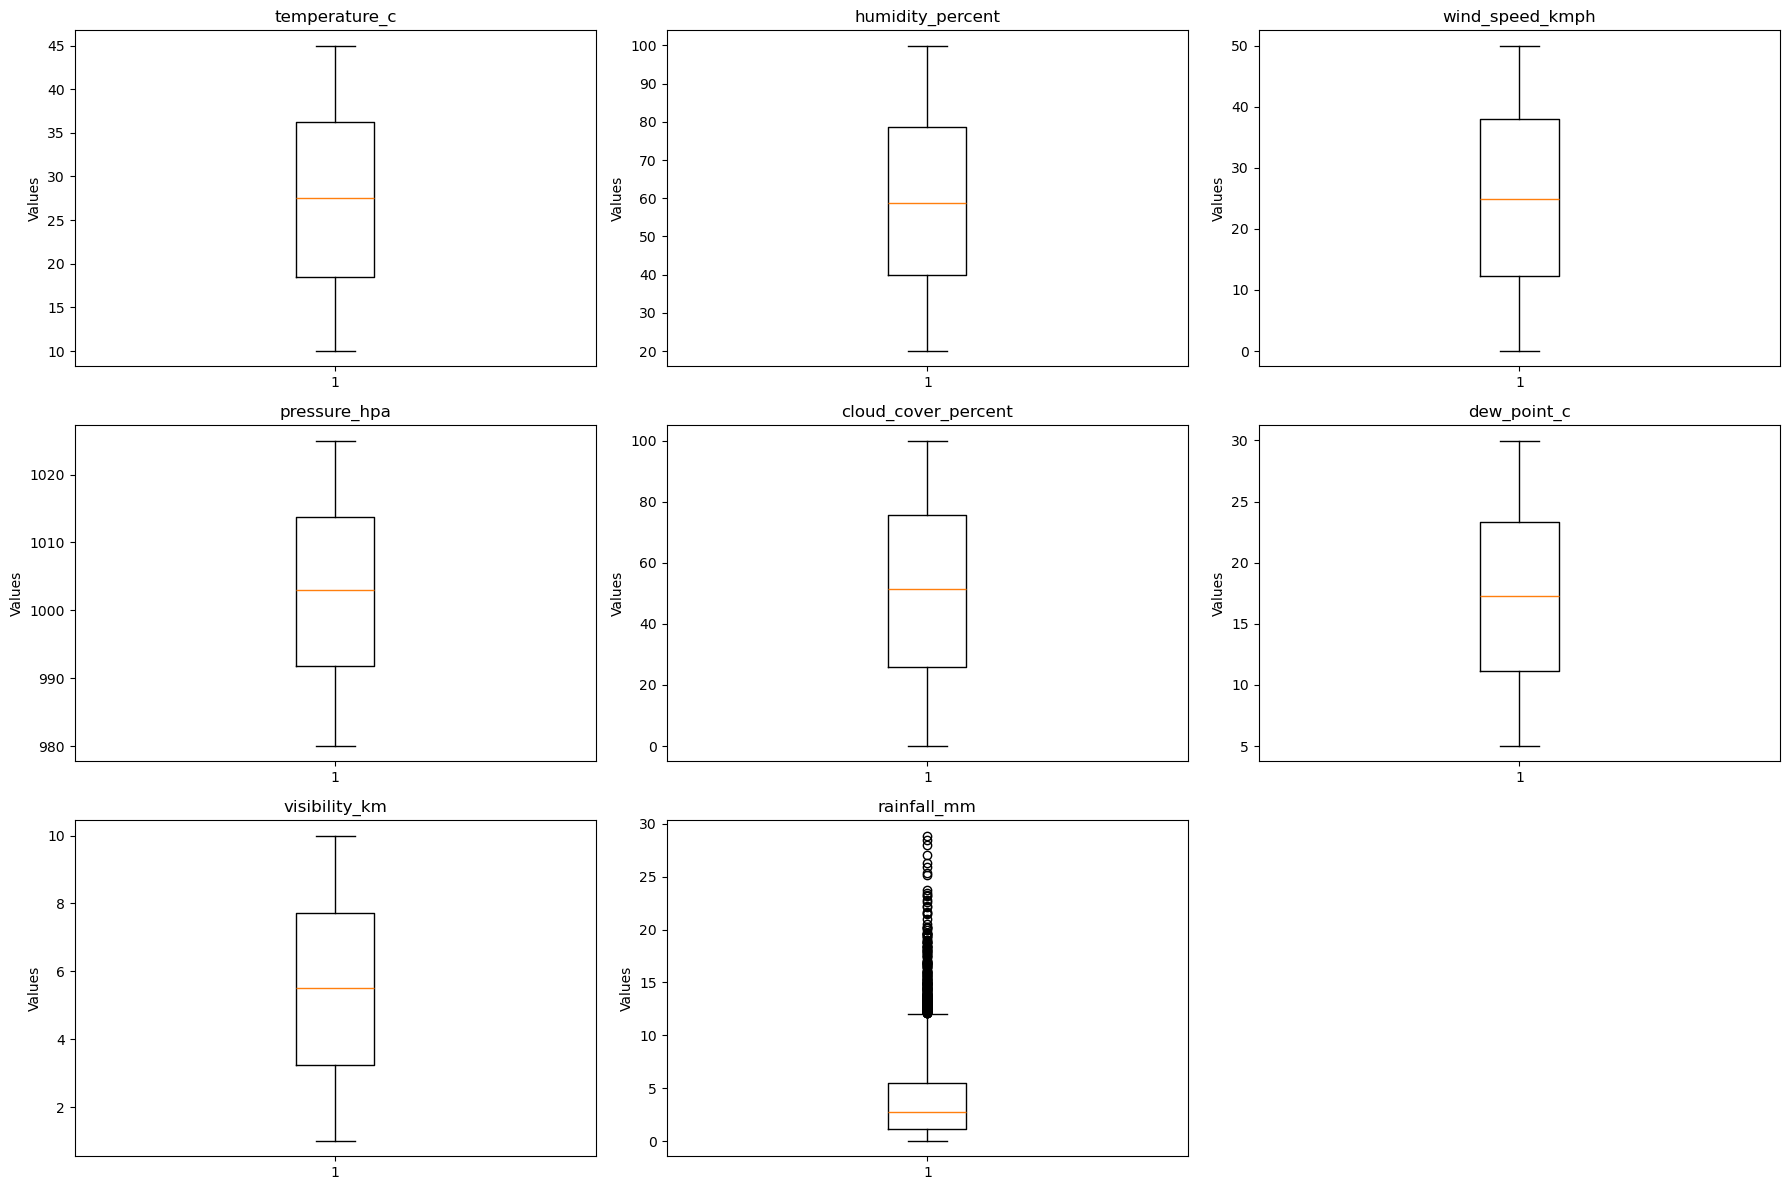

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Figure size
plt.figure(figsize=(18, 12))

# Create boxplots
for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols)+2)//3, 3, i)

    plt.boxplot(df[col], vert=True)

    plt.title(col)
    plt.ylabel("Values")

# Adjust layout
plt.tight_layout()
plt.savefig('boxplots.png')  # Save the figure

# Show plots
plt.show()

In [23]:
# Cell 6 — log-transform rainfall (fixes the skew you saw in the box plot)
df['rainfall_log'] = np.log1p(df['rainfall_mm'])   # log1p handles zeros safely

In [24]:
df.head()

,date,temperature_c,humidity_percent,wind_speed_kmph,pressure_hpa,cloud_cover_percent,dew_point_c,visibility_km,rainfall_mm,rainfall_log
0,2018-01-01,23.11,51.49,18.68,1002.49,73.00,7.31,6.74,3.76,1.560248
1,2018-01-02,43.28,57.87,16.65,1013.60,18.45,6.52,5.13,0.16,0.148420
2,2018-01-03,35.62,88.36,8.81,1005.32,34.66,20.10,9.68,3.79,1.566530
3,2018-01-04,30.95,47.20,30.36,983.75,66.33,29.15,2.97,0.38,0.322083
4,2018-01-05,15.46,89.57,23.83,988.35,48.21,17.57,6.29,4.96,1.785070


In [25]:
# Cell 7 — scale features with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df_scaled.head()

,date,temperature_c,humidity_percent,wind_speed_kmph,pressure_hpa,cloud_cover_percent,dew_point_c,visibility_km,rainfall_mm,rainfall_log
0,2018-01-01,-0.422157,-0.342669,-0.439480,-0.027476,0.766238,-1.402069,0.475788,-0.049134,1.560248
1,2018-01-02,1.567737,-0.063421,-0.579123,0.830437,-1.123181,-1.513132,-0.144707,-0.969842,0.148420
2,2018-01-03,0.812031,1.271106,-1.118433,0.191056,-0.561724,0.396020,1.608866,-0.041462,1.566530
3,2018-01-04,0.351307,-0.530440,0.363983,-1.474576,0.535213,1.668318,-0.977173,-0.913577,0.322083
4,2018-01-05,-1.176877,1.324067,-0.085213,-1.119365,-0.092400,0.040338,0.302358,0.257769,1.785070
